# Toxic Comment Classifier by Julio Beckman

A binary toxicity classifier for social media comments, comparing three progressively complex approaches:

1. **Baseline**: TF-IDF (unigrams) + Logistic Regression
2. **Improved**: TF-IDF (uni+bigrams) + Linear SVM
3. **DistilBERT**: Fine-tuned transformer with weighted cross-entropy loss

Trained on the [Jigsaw Toxic Comment Classification](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge) and [Jigsaw Unintended Bias](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification) datasets.

**Key techniques:** random oversampling, class-weighted loss, and threshold tuning to address the ~90/10 class imbalance in the dataset.

---
## 1. Setup

In [4]:
# core dependencies — consolidated here to avoid duplicate imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import re
import os
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

In [5]:
import sklearn
print(sklearn.__version__)


1.6.1


In [6]:
# install huggingface libraries (colab only)
!pip install -q transformers datasets accelerate

In [7]:
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

In [8]:
# mount google drive to access datasets stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 2. Utility Functions

These are reused throughout the notebook — text cleaning for preprocessing, metric helpers for evaluation, and threshold tuning for post-training optimization.

In [9]:
# --- text cleaning ---
# precompile regex patterns so they aren't rebuilt on every function call
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
USER_PATTERN = re.compile(r'@\w+')
NEWLINE_PATTERN = re.compile(r'\n+')


def clean_comment(text: str) -> str:
    """Normalize a raw comment for model input.

    Lowercases, replaces URLs and @mentions with tokens,
    collapses whitespace. Keeps punctuation and special
    characters intact since they can carry sentiment signal.
    """
    text = text.lower()
    text = URL_PATTERN.sub(' URL ', text)
    text = USER_PATTERN.sub(' USER ', text)
    text = NEWLINE_PATTERN.sub(' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# --- evaluation helpers ---
def get_scores(y_true, y_pred, model_name):
    """Compute binary classification metrics for the toxic (positive) class."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1
    )
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_delete': precision,
        'recall_delete': recall,
        'f1_delete': f1,
    }


def error_stats(name, y_true, y_pred):
    """Print false positive and false negative counts for a model."""
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    print(f"{name}: {fp} false positives, {fn} false negatives")


# --- threshold tuning ---
def find_best_threshold(y_true, probabilities, thresholds=None):
    """Sweep decision thresholds to maximize F1 on the toxic class.

    Instead of using the default 0.5 cutoff, this tests thresholds
    from 0.10 to 0.90 and picks the one that produces the best F1
    score on the provided labels. Should be run on the validation
    set, then applied to the test set.
    """
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    results = []
    for t in thresholds:
        preds = (probabilities >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, preds, average='binary', pos_label=1, zero_division=0
        )
        results.append({'threshold': t, 'precision': p, 'recall': r, 'f1': f1})

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df['f1'].idxmax()]
    return best_row['threshold'], results_df

---
## 3. Data Loading & Label Engineering

In [10]:
# load the primary jigsaw toxic comment dataset
file_path = '/content/drive/MyDrive/NLPFinalProject/data/train.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f'Dataset not found at {file_path}')

df = pd.read_csv(file_path)
print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows: 159571
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [11]:
# collapse the six toxicity sub-labels into a single binary target.
# a comment is marked "delete" if ANY of the six labels is 1,
# since any form of toxicity warrants moderation action.
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df[label_cols] = df[label_cols].fillna(0)
df['delete'] = (df[label_cols].max(axis=1) > 0).astype(int)

print(df['delete'].value_counts(normalize=True))

delete
0    0.898321
1    0.101679
Name: proportion, dtype: float64


---
## 4. Train / Validation / Test Split

70/15/15 split with stratification to preserve the class ratio in each partition. Stratification is critical here because with ~10% toxic comments, a random split could produce validation or test sets with significantly different class distributions.

In [12]:
df['comment_text'] = df['comment_text'].fillna('')

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['delete'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['delete'], random_state=42
)

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name}: {part.shape}, toxic rate: {part["delete"].mean():.3f}')

train: (111699, 9), toxic rate: 0.102
val: (23936, 9), toxic rate: 0.102
test: (23936, 9), toxic rate: 0.102


---
## 5. Bias Dataset Integration

The primary Jigsaw dataset is heavily skewed toward explicit toxicity (profanity, slurs). The [Jigsaw Unintended Bias dataset](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification) provides broader coverage of subtle and identity-based toxicity. We sample 100k rows to keep training time manageable and append them to the training set only — validation and test sets remain untouched.

In [13]:
bias_file_path = '/content/drive/MyDrive/NLPFinalProject/data/bias_train.csv'
bias_df = pd.read_csv(bias_file_path)

# the bias dataset uses continuous toxicity scores (0.0–1.0) instead of
# binary labels. threshold at 0.5 to match our binary "delete" column.
bias_df['delete'] = (bias_df['severe_toxicity'] >= 0.5).astype(int)
bias_df = bias_df[['comment_text', 'delete']]
bias_df['comment_text'] = bias_df['comment_text'].fillna('')

bias_df = bias_df.sample(n=100_000, random_state=42)
print(f'Bias dataset sample: {len(bias_df)} rows, {bias_df["delete"].mean():.2%} toxic')

# append to training data only
train_df = pd.concat([train_df, bias_df], ignore_index=True)
print(f'Combined training set: {len(train_df)} rows, {train_df["delete"].mean():.2%} toxic')

Bias dataset sample: 100000 rows, 0.00% toxic
Combined training set: 211699 rows, 5.37% toxic


---
## 6. Class Imbalance — Oversampling

Even after adding the bias data, the training set is still imbalanced. We randomly duplicate minority-class (toxic) examples until both classes are equal. This is done with replacement, so some toxic comments appear multiple times — the model effectively sees them more often during training.

We only oversample the training set. Oversampling validation or test data would produce artificially inflated metrics.

In [14]:
train_majority = train_df[train_df['delete'] == 0]
train_minority = train_df[train_df['delete'] == 1]

print(f'Before oversampling:')
print(f'  non-toxic: {len(train_majority)}')
print(f'  toxic:     {len(train_minority)}')
print(f'  ratio:     {len(train_majority) / len(train_minority):.1f}:1')

# upsample minority class to match majority class count
train_minority_upsampled = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=42,
)

train_df_balanced = pd.concat([train_majority, train_minority_upsampled])
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nAfter oversampling:')
print(f'  non-toxic: {len(train_df_balanced[train_df_balanced["delete"] == 0])}')
print(f'  toxic:     {len(train_df_balanced[train_df_balanced["delete"] == 1])}')
print(f'  total:     {len(train_df_balanced)}')

Before oversampling:
  non-toxic: 200341
  toxic:     11358
  ratio:     17.6:1

After oversampling:
  non-toxic: 200341
  toxic:     200341
  total:     400682


---
## 7. Text Preprocessing

In [15]:
# apply the clean_comment function defined in utilities
for part in [train_df, train_df_balanced, val_df, test_df]:
    part['clean_text'] = part['comment_text'].apply(clean_comment)

train_df[['comment_text', 'clean_text']].head()

,comment_text,clean_text
0,"""\n\n Islands in the Caribbean \n\nWondering w...",""" islands in the caribbean wondering why you r..."
1,"""add the complaint, however please read the in...","""add the complaint, however please read the in..."
2,"""I suggest that there be a """"Lincoln High Scho...","""i suggest that there be a """"lincoln high scho..."
3,oi \n\nI've had enough of your threats mr. Sor...,oi i've had enough of your threats mr. sort yo...
4,Article To Long ?!\n\nI am wondering if the Do...,article to long ?! i am wondering if the dog a...


In [16]:
# extract features and labels for sklearn models.
# we use the balanced training set so models see equal class counts.
X_train = train_df_balanced['clean_text'].values
y_train = train_df_balanced['delete'].values

X_val = val_df['clean_text'].values
y_val = val_df['delete'].values

X_test = test_df['clean_text'].values
y_test = test_df['delete'].values

---
## 8. Model 1 — Baseline (TF-IDF Unigrams + Logistic Regression)

The simplest reasonable approach: convert text to TF-IDF unigram features and fit a logistic regression. `class_weight='balanced'` adjusts the loss function to penalize misclassified toxic comments more heavily, acting as a second layer of imbalance handling on top of oversampling.

In [17]:
baseline_clf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1, 1))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
])

baseline_clf.fit(X_train, y_train)

y_val_pred = baseline_clf.predict(X_val)
y_test_pred = baseline_clf.predict(X_test)

print('BASELINE — validation')
print(f'accuracy: {accuracy_score(y_val, y_val_pred):.4f}')
print(classification_report(y_val, y_val_pred, digits=4))

print('BASELINE — test')
print(f'accuracy: {accuracy_score(y_test, y_test_pred):.4f}')
print(classification_report(y_test, y_test_pred, digits=4))

BASELINE — validation
accuracy: 0.9371
              precision    recall  f1-score   support

           0     0.9814    0.9480    0.9644     21502
           1     0.6467    0.8414    0.7313      2434

    accuracy                         0.9371     23936
   macro avg     0.8140    0.8947    0.8478     23936
weighted avg     0.9474    0.9371    0.9407     23936

BASELINE — test
accuracy: 0.9335
              precision    recall  f1-score   support

           0     0.9793    0.9460    0.9623     21502
           1     0.6330    0.8233    0.7157      2434

    accuracy                         0.9335     23936
   macro avg     0.8061    0.8846    0.8390     23936
weighted avg     0.9441    0.9335    0.9373     23936



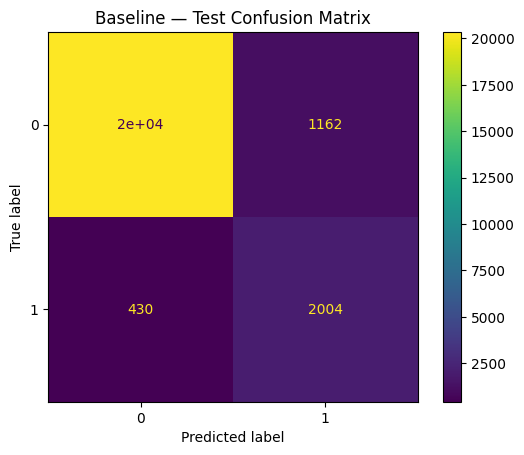

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title('Baseline — Test Confusion Matrix')
plt.show()

---
## 9. Model 2 — Improved (TF-IDF Uni+Bigrams + Linear SVM)

Two improvements over baseline: (1) bigrams capture two-word phrases like "kill yourself" or "go back" that unigrams miss, and (2) Linear SVM often outperforms logistic regression on high-dimensional sparse text features because it optimizes for the maximum-margin decision boundary.

In [19]:
improved_clf_1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=5,
    )),
    ('clf', LinearSVC(class_weight='balanced')),
])

improved_clf_1.fit(X_train, y_train)

y_val_pred_imp1 = improved_clf_1.predict(X_val)
y_test_pred_imp1 = improved_clf_1.predict(X_test)

print('IMPROVED (SVM) — validation')
print(f'accuracy: {accuracy_score(y_val, y_val_pred_imp1):.4f}')
print(classification_report(y_val, y_val_pred_imp1, digits=4))

print('IMPROVED (SVM) — test')
print(f'accuracy: {accuracy_score(y_test, y_test_pred_imp1):.4f}')
print(classification_report(y_test, y_test_pred_imp1, digits=4))

IMPROVED (SVM) — validation
accuracy: 0.9524
              precision    recall  f1-score   support

           0     0.9667    0.9808    0.9737     21502
           1     0.8052    0.7013    0.7497      2434

    accuracy                         0.9524     23936
   macro avg     0.8859    0.8411    0.8617     23936
weighted avg     0.9503    0.9524    0.9509     23936

IMPROVED (SVM) — test
accuracy: 0.9530
              precision    recall  f1-score   support

           0     0.9673    0.9809    0.9740     21502
           1     0.8071    0.7067    0.7536      2434

    accuracy                         0.9530     23936
   macro avg     0.8872    0.8438    0.8638     23936
weighted avg     0.9510    0.9530    0.9516     23936



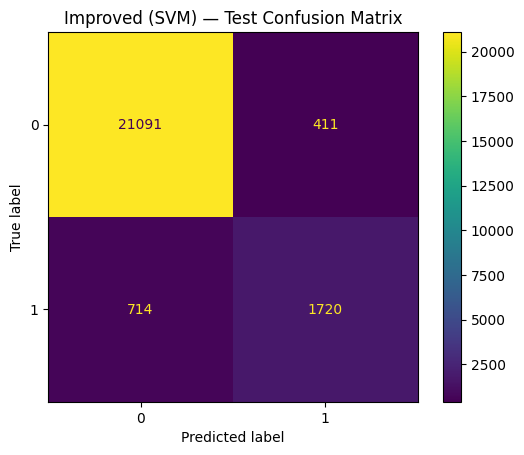

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_imp1)
plt.title('Improved (SVM) — Test Confusion Matrix')
plt.show()

---
## 10. Model 3 — DistilBERT with Weighted Loss

DistilBERT is a smaller, faster variant of BERT that retains ~97% of its language understanding. Unlike TF-IDF, it produces contextual embeddings — the same word gets different representations depending on surrounding context. This should help with nuanced cases.

To address class imbalance at the model level, we subclass HuggingFace's `Trainer` to inject a weighted `CrossEntropyLoss`. The weights are computed from the training label distribution using sklearn's `compute_class_weight`, which assigns higher penalty to the underrepresented toxic class.

In [21]:
# sample from the balanced training set for transformer fine-tuning.
# 80k rows balances training time vs. performance on a T4 GPU.
train_small = train_df_balanced.sample(
    n=min(80_000, len(train_df_balanced)), random_state=42
)
val_small = val_df.copy()
test_small = test_df.copy()


def to_hf_dataset(dataframe):
    """Convert a pandas dataframe to a HuggingFace Dataset."""
    tmp = dataframe[['clean_text', 'delete']].rename(
        columns={'clean_text': 'text', 'delete': 'label'}
    )
    return Dataset.from_pandas(tmp.reset_index(drop=True))


hf_dataset = DatasetDict({
    'train': to_hf_dataset(train_small),
    'validation': to_hf_dataset(val_small),
    'test': to_hf_dataset(test_small),
})

hf_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 80000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 23936
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 23936
    })
})

In [22]:
# tokenize all splits using DistilBERT's tokenizer.
# max_length=128 truncates long comments — most toxic comments
# are short, so this captures the vast majority of signal.
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)


def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, padding=False, max_length=128)


tokenized_datasets = hf_dataset.map(tokenize_batch, batched=True, remove_columns=['text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/23936 [00:00<?, ? examples/s]

Map:   0%|          | 0/23936 [00:00<?, ? examples/s]

In [23]:
# load pretrained DistilBERT and add a 2-class classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


def compute_metrics(eval_pred):
    """Compute metrics during training for early stopping on F1."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', pos_label=1
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
# compute class weights from the training labels so the loss function
# penalizes misclassified toxic comments proportionally to their scarcity.
# sklearn's compute_class_weight('balanced') produces weights inversely
# proportional to class frequency: w_i = n_samples / (n_classes * n_i)
train_labels = tokenized_datasets['train']['label']

class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=train_labels
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f'class weights — non-toxic: {class_weights[0]:.4f}, toxic: {class_weights[1]:.4f}')
print(f'device: {device}')

class weights — non-toxic: 1.0025, toxic: 0.9976
device: cuda


In [25]:
class WeightedTrainer(Trainer):
    """Custom Trainer that replaces the default loss with weighted CrossEntropyLoss.

    The standard Trainer treats both classes equally. With imbalanced data,
    this means the model is barely penalized for missing toxic comments
    (the minority class). WeightedTrainer applies precomputed class weights
    to CrossEntropyLoss so that a missed toxic comment incurs a higher loss
    than a missed non-toxic one.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [26]:
# training configuration — 2 epochs with early stopping on F1.
# load_best_model_at_end ensures we keep the checkpoint with
# the highest validation F1 rather than the final epoch.
training_args = TrainingArguments(
    output_dir='distilbert-toxic',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [27]:
# disable wandb logging and train
os.environ['WANDB_DISABLED'] = 'true'

trainer.train()

bert_eval = trainer.evaluate(tokenized_datasets['test'])
bert_eval

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.096426,0.208229,0.941218,0.653329,0.898932,0.756701
2,0.053786,0.250472,0.950033,0.699935,0.890304,0.783725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'eval_loss': 0.258415162563324,
 'eval_accuracy': 0.9481951871657754,
 'eval_precision': 0.6933290155440415,
 'eval_recall': 0.8796220213640099,
 'eval_f1': 0.7754436798261499,
 'eval_runtime': 22.0848,
 'eval_samples_per_second': 1083.824,
 'eval_steps_per_second': 33.87,
 'epoch': 2.0}

In [28]:
# generate predictions on the test set
bert_predictions = trainer.predict(tokenized_datasets['test'])
bert_logits = bert_predictions.predictions
bert_preds = np.argmax(bert_logits, axis=-1)

# ground truth labels aligned with test_small
y_test_bert = test_small['delete'].values

---
## 11. Threshold Tuning

All models default to a 0.5 decision threshold, but with imbalanced data the optimal threshold is often lower — the model may only assign 0.35 probability to a genuinely toxic comment because it's been trained on overwhelmingly non-toxic examples.

We sweep thresholds on the **validation set** and pick the one that maximizes F1 for the toxic class, then apply it to the test set.

In [29]:
# threshold tuning for baseline (logistic regression outputs probabilities)
baseline_val_proba = baseline_clf.predict_proba(X_val)[:, 1]
best_thresh_baseline, baseline_thresh_results = find_best_threshold(y_val, baseline_val_proba)

print(f'baseline — optimal threshold: {best_thresh_baseline:.2f}')

# apply tuned threshold to test set
baseline_test_proba = baseline_clf.predict_proba(X_test)[:, 1]
y_test_pred_tuned_baseline = (baseline_test_proba >= best_thresh_baseline).astype(int)

baseline — optimal threshold: 0.75


In [30]:
# threshold tuning for DistilBERT.
# softmax converts raw logits to probabilities, then we take P(toxic).
val_predictions = trainer.predict(tokenized_datasets['validation'])
val_logits = val_predictions.predictions
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()[:, 1]

y_val_bert = val_small['delete'].values
best_thresh_bert, bert_thresh_results = find_best_threshold(y_val_bert, val_probs)

print(f'DistilBERT — optimal threshold: {best_thresh_bert:.2f}')

# apply tuned threshold to test set
test_probs_bert = torch.softmax(torch.tensor(bert_logits), dim=-1).numpy()[:, 1]
bert_preds_tuned = (test_probs_bert >= best_thresh_bert).astype(int)

DistilBERT — optimal threshold: 0.90


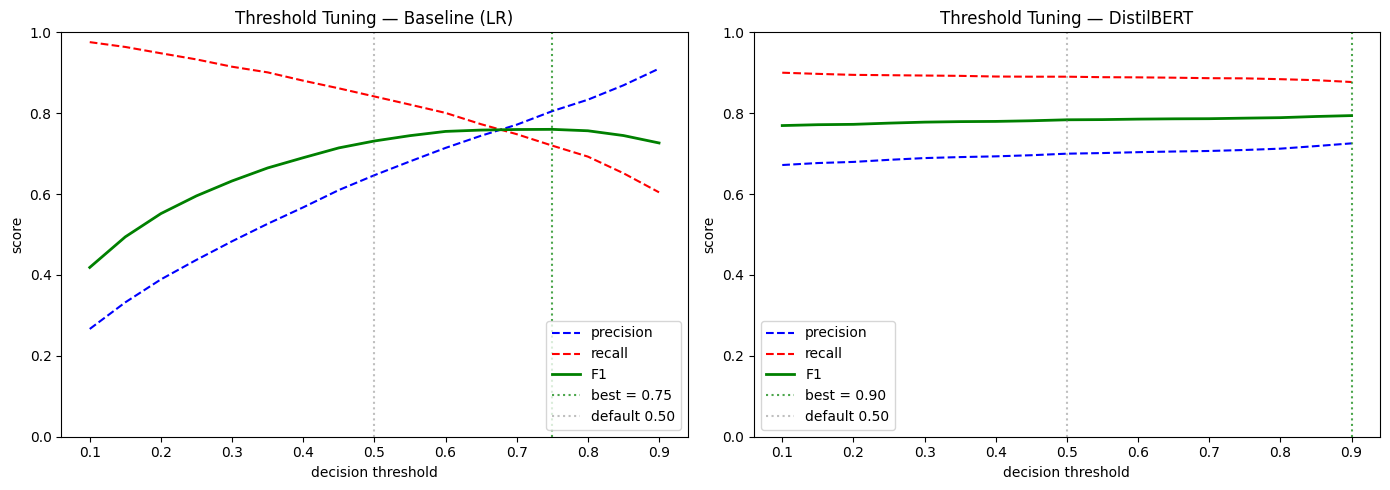

In [31]:
# visualize the precision-recall-f1 tradeoff across thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_thresh, title, best_t in [
    (axes[0], baseline_thresh_results, 'Baseline (LR)', best_thresh_baseline),
    (axes[1], bert_thresh_results, 'DistilBERT', best_thresh_bert),
]:
    ax.plot(df_thresh['threshold'], df_thresh['precision'], 'b--', label='precision')
    ax.plot(df_thresh['threshold'], df_thresh['recall'], 'r--', label='recall')
    ax.plot(df_thresh['threshold'], df_thresh['f1'], 'g-', label='F1', linewidth=2)
    ax.axvline(x=best_t, color='green', linestyle=':', alpha=0.7, label=f'best = {best_t:.2f}')
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='default 0.50')
    ax.set_xlabel('decision threshold')
    ax.set_ylabel('score')
    ax.set_title(f'Threshold Tuning — {title}')
    ax.legend(loc='best')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [32]:
# compare default vs tuned threshold performance
print('=' * 65)
print('IMPACT OF THRESHOLD TUNING ON TEST SET')
print('=' * 65)

print('\n--- baseline (logistic regression) ---')
print('\ndefault threshold (0.50):')
print(classification_report(y_test, y_test_pred, digits=4, target_names=['keep', 'delete']))
print(f'tuned threshold ({best_thresh_baseline:.2f}):')
print(classification_report(y_test, y_test_pred_tuned_baseline, digits=4, target_names=['keep', 'delete']))

print('\n--- DistilBERT ---')
print('\ndefault threshold (0.50):')
print(classification_report(y_test_bert, bert_preds, digits=4, target_names=['keep', 'delete']))
print(f'tuned threshold ({best_thresh_bert:.2f}):')
print(classification_report(y_test_bert, bert_preds_tuned, digits=4, target_names=['keep', 'delete']))

IMPACT OF THRESHOLD TUNING ON TEST SET

--- baseline (logistic regression) ---

default threshold (0.50):
              precision    recall  f1-score   support

        keep     0.9793    0.9460    0.9623     21502
      delete     0.6330    0.8233    0.7157      2434

    accuracy                         0.9335     23936
   macro avg     0.8061    0.8846    0.8390     23936
weighted avg     0.9441    0.9335    0.9373     23936

tuned threshold (0.75):
              precision    recall  f1-score   support

        keep     0.9687    0.9809    0.9747     21502
      delete     0.8100    0.7198    0.7622      2434

    accuracy                         0.9543     23936
   macro avg     0.8893    0.8503    0.8685     23936
weighted avg     0.9525    0.9543    0.9531     23936


--- DistilBERT ---

default threshold (0.50):
              precision    recall  f1-score   support

        keep     0.9859    0.9560    0.9707     21502
      delete     0.6933    0.8796    0.7754      2434

    a

---
## 12. Model Comparison

In [33]:
# aggregate test set metrics across all three models
results = [
    get_scores(y_test, y_test_pred, 'Baseline (TF-IDF uni + LR)'),
    get_scores(y_test, y_test_pred_imp1, 'Improved 1 (TF-IDF uni+bi + SVM)'),
    get_scores(y_test_bert, bert_preds, 'Improved 2 (DistilBERT)'),
]

results_df = pd.DataFrame(results)
display(results_df)

,model,accuracy,precision_delete,recall_delete,f1_delete
0,Baseline (TF-IDF uni + LR),0.933489,0.632975,0.823336,0.715714
1,Improved 1 (TF-IDF uni+bi + SVM),0.953000,0.807133,0.706656,0.753560
2,Improved 2 (DistilBERT),0.948195,0.693329,0.879622,0.775444


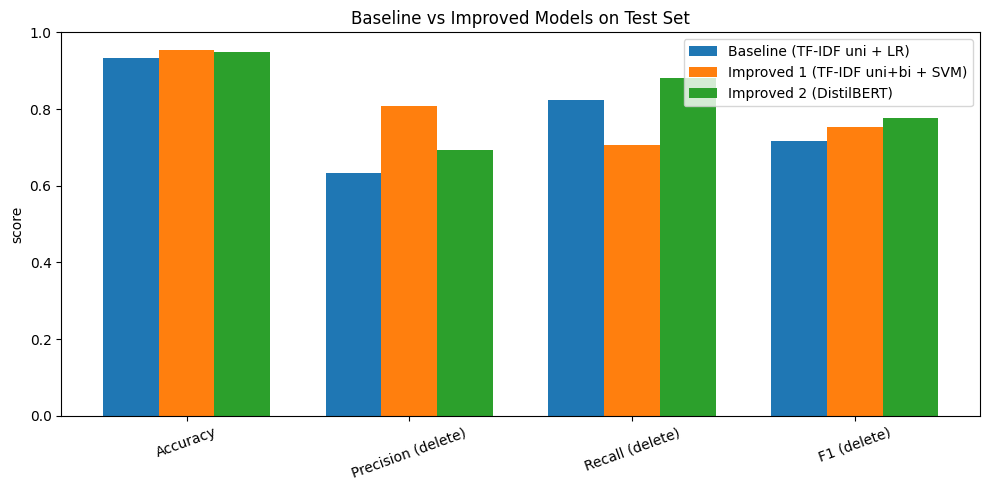

In [34]:
# grouped bar chart comparing all models across four metrics
metrics = ['accuracy', 'precision_delete', 'recall_delete', 'f1_delete']
metric_labels = ['Accuracy', 'Precision (delete)', 'Recall (delete)', 'F1 (delete)']

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
for i, row in results_df.iterrows():
    plt.bar(x + i * width, [row[m] for m in metrics], width, label=row['model'])

plt.xticks(x + width, metric_labels, rotation=20)
plt.ylim(0, 1)
plt.ylabel('score')
plt.title('Baseline vs Improved Models on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

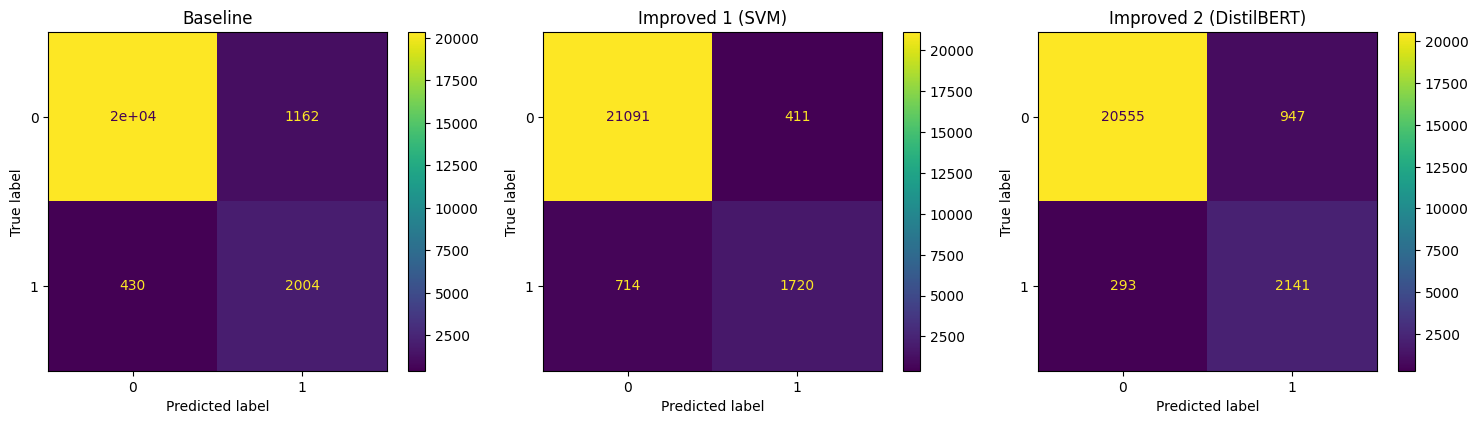

In [35]:
# side-by-side confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_for_cm = [
    ('Baseline', y_test, y_test_pred),
    ('Improved 1 (SVM)', y_test, y_test_pred_imp1),
    ('Improved 2 (DistilBERT)', y_test_bert, bert_preds),
]

for ax, (name, y_true, y_pred) in zip(axes, models_for_cm):
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

---
## 13. Error Analysis

In [36]:
# false positive / false negative counts per model
print('Error summary on test set:\n')
error_stats('Baseline (TF-IDF uni + LR)', y_test, y_test_pred)
error_stats('Improved 1 (TF-IDF uni+bi + SVM)', y_test, y_test_pred_imp1)
error_stats('Improved 2 (DistilBERT)', y_test_bert, bert_preds)

Error summary on test set:

Baseline (TF-IDF uni + LR): 1162 false positives, 430 false negatives
Improved 1 (TF-IDF uni+bi + SVM): 411 false positives, 714 false negatives
Improved 2 (DistilBERT): 947 false positives, 293 false negatives


In [37]:
# inspect specific misclassifications from DistilBERT.
# false positives = safe comments incorrectly flagged as toxic.
# false negatives = toxic comments that slipped through.
y_true = y_test_bert
y_pred = bert_preds
texts = test_small['comment_text'].values

false_positives = (y_true == 0) & (y_pred == 1)
false_negatives = (y_true == 1) & (y_pred == 0)

print('FALSE POSITIVES (model predicted delete, label is keep):\n')
for i in np.where(false_positives)[0][:5]:
    print(f'[text]  {texts[i]}')
    print(f'[label] delete={y_true[i]}, [pred] {y_pred[i]}\n---')

print('\nFALSE NEGATIVES (model predicted keep, label is delete):\n')
for i in np.where(false_negatives)[0][:5]:
    print(f'[text]  {texts[i]}')
    print(f'[label] delete={y_true[i]}, [pred] {y_pred[i]}\n---')

FALSE POSITIVES (model predicted delete, label is keep):

[text]  Biased, unreliable,emotionally written by armenin wiki editors==
Pls, stop using the wikipedia for your dirty propaganda and lobbying purposes. There was no genocide. THis is a amyth advanced by the armenian church and armenian fundamentalist fascists. A nation can not be subject to a egnocide when it has several heros for whom you can see statues in yerevan (Irevan),. jews don't have it. The resolution is the act of some sold congressmen who want to appease the armenian lobby. it has no reliable, valid and neutral content. It is kjust a piece of dirty and lie facts presented and written by christian missionaries working to kill Turks and Kurds in 1910s. You can claim to be subject to genocide as much as you want. But this thing did never happen. Some armenian fundamentalists and fascists, who were killing Kurds, Turks and Azerbaijanis, were killed by great sons of the Turkic nation and I am proud of them. Go and propoga

---
## 14. Interactive Demo

The `test_comment()` function runs a single comment through all three models and displays the prediction, confidence, and whether the tuned threshold changed the outcome.

In [38]:
LABEL_MAP = {
    0: 'KEEP (non-toxic / safe)',
    1: 'DELETE (toxic / hateful)',
}

# ensure model is on the correct device
device = next(model.parameters()).device


def test_comment(text: str):
    """Classify a comment with all three models and print results."""
    cleaned = clean_comment(text)

    print(f'original: {text}')
    print(f'cleaned:  {cleaned}')
    print('-' * 60)

    # baseline — logistic regression outputs calibrated probabilities
    base_proba = baseline_clf.predict_proba([cleaned])[0][1]
    base_pred = int(base_proba >= best_thresh_baseline)

    # improved — LinearSVC outputs a decision function (signed distance
    # to the hyperplane), not probabilities. positive = toxic.
    imp1_pred = improved_clf_1.predict([cleaned])[0]
    imp1_score = improved_clf_1.decision_function([cleaned])[0]

    # DistilBERT — run forward pass with no gradient computation,
    # convert logits to probabilities via softmax, then apply
    # the tuned threshold instead of the default 0.5
    inputs = tokenizer(
        cleaned, return_tensors='pt', truncation=True, padding=True, max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
    bert_pred = int(probs[1] >= best_thresh_bert)
    bert_proba = probs[1]

    print(f'baseline (LR):       {LABEL_MAP[base_pred]}  (P(delete) = {base_proba:.3f})')
    print(f'improved (SVM):      {LABEL_MAP[imp1_pred]}  (decision score = {imp1_score:.3f})')
    print(f'DistilBERT:          {LABEL_MAP[bert_pred]}  (P(delete) = {bert_proba:.3f})')

In [39]:
# curated edge cases that test specific failure modes:
# tone vs. content, victim vs. aggressor, reclaimed language,
# implicit bias, obfuscation, and code-switching
edge_cases = [
    'I am so tired of this nonsense, but I still respect your opinion.',
    'You are absolutely clueless and completely incompetent at this.',
    'If you keep talking like that, something bad might happen to you.',
    'Keep it up and I will find you and make you regret it.',
    "They keep calling me stupid in the group chat and it's really hurting me.",
    "Our community decided to reclaim the word 'queer' and use it with pride.",
    "Saying 'go back to your country' is racist and should never be tolerated.",
    "I just think people like you shouldn't be allowed to vote, that's all.",
    'You p3ople are a d1sgrace to this country.',
    'Honestly, tu opinión es una basura and you know it.',
]

for text in edge_cases:
    print('=' * 80)
    test_comment(text)

original: I am so tired of this nonsense, but I still respect your opinion.
cleaned:  i am so tired of this nonsense, but i still respect your opinion.
------------------------------------------------------------
baseline (LR):       KEEP (non-toxic / safe)  (P(delete) = 0.284)
improved (SVM):      KEEP (non-toxic / safe)  (decision score = -1.704)
DistilBERT:          KEEP (non-toxic / safe)  (P(delete) = 0.000)
original: You are absolutely clueless and completely incompetent at this.
cleaned:  you are absolutely clueless and completely incompetent at this.
------------------------------------------------------------
baseline (LR):       KEEP (non-toxic / safe)  (P(delete) = 0.485)
improved (SVM):      KEEP (non-toxic / safe)  (decision score = -0.342)
DistilBERT:          DELETE (toxic / hateful)  (P(delete) = 0.948)
original: If you keep talking like that, something bad might happen to you.
cleaned:  if you keep talking like that, something bad might happen to you.
-----------------

In [40]:
# adversarial and stress-test cases organized by failure category
adversarial_cases = [
    # adversarial misspellings and evasion
    'You are an iD1ot.',
    'F.u.c.k you!',
    'You s-u-c-k',
    'Y O U  A R E  S T U P I D',
    'You\nAre\nTrash',

    # sarcasm and implicit toxicity
    'Oh, brilliant idea. Because that worked so well last time, genius.',
    "I'm not saying he's stupid, but if IQ were money, he'd be bankrupt.",
    'Wow, you must be really proud of that mess.',

    # context-dependent and counter-speech
    'Stop calling people the n-word.',
    'That is so gay (meaning stupid).',

    # false positives — benign use of flagged keywords
    'I hate cold weather.',
    'This movie is absolutely killer!',
    "Let's kill this project and start over.",

    # severe toxicity
    'I hope you get in a car crash.',
    'Kill yourself.',
    'Go back to your country.',

    # multilingual
    'Eres una basura.',
]

for text in adversarial_cases:
    print('=' * 80)
    test_comment(text)

original: You are an iD1ot.
cleaned:  you are an id1ot.
------------------------------------------------------------
baseline (LR):       DELETE (toxic / hateful)  (P(delete) = 0.929)
improved (SVM):      DELETE (toxic / hateful)  (decision score = 0.630)
DistilBERT:          KEEP (non-toxic / safe)  (P(delete) = 0.045)
original: F.u.c.k you!
cleaned:  f.u.c.k you!
------------------------------------------------------------
baseline (LR):       DELETE (toxic / hateful)  (P(delete) = 0.993)
improved (SVM):      DELETE (toxic / hateful)  (decision score = 2.544)
DistilBERT:          DELETE (toxic / hateful)  (P(delete) = 0.999)
original: You s-u-c-k
cleaned:  you s-u-c-k
------------------------------------------------------------
baseline (LR):       DELETE (toxic / hateful)  (P(delete) = 0.993)
improved (SVM):      DELETE (toxic / hateful)  (decision score = 2.544)
DistilBERT:          DELETE (toxic / hateful)  (P(delete) = 0.980)
original: Y O U  A R E  S T U P I D
cleaned:  y o u a 

---
## 15. Save / Load Models

Persist trained models to Google Drive to avoid retraining. The Gradio demo app (`app.py`) loads from the same `models/` directory.

In [41]:
# save all trained models and configuration to google drive
save_dir = '/content/drive/MyDrive/NLPFinalProject/models/'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(baseline_clf, save_dir + 'baseline_clf.joblib')
joblib.dump(improved_clf_1, save_dir + 'improved_clf_1.joblib')

model.save_pretrained(save_dir + 'distilbert-toxic')
tokenizer.save_pretrained(save_dir + 'distilbert-toxic')

config = {
    'best_thresh_baseline': best_thresh_baseline,
    'best_thresh_bert': best_thresh_bert,
}
with open(save_dir + 'config.json', 'w') as f:
    json.dump(config, f)

print('all models and config saved to:', save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

all models and config saved to: /content/drive/MyDrive/NLPFinalProject/models/


In [42]:
# # load saved models (uncomment this cell to skip training)
#
# save_dir = '/content/drive/MyDrive/NLPFinalProject/models/'
#
# baseline_clf = joblib.load(save_dir + 'baseline_clf.joblib')
# improved_clf_1 = joblib.load(save_dir + 'improved_clf_1.joblib')
#
# model = AutoModelForSequenceClassification.from_pretrained(save_dir + 'distilbert-toxic')
# tokenizer = AutoTokenizer.from_pretrained(save_dir + 'distilbert-toxic')
#
# with open(save_dir + 'config.json', 'r') as f:
#     config = json.load(f)
# best_thresh_baseline = config['best_thresh_baseline']
# best_thresh_bert = config['best_thresh_bert']
#
# print('all models loaded from:', save_dir)

---
## Known Limitations & Future Work

While the model performs well on explicit toxicity (profanity, direct insults, overt threats), edge-case testing revealed several categories of failure that reflect fundamental limitations of the dataset and approach.

### 1. Implicit Hate Speech and Conspiracy Tropes

The model fails to flag statements like *"jews control the world"* or *"I just think people like you shouldn't be allowed to vote."* These express exclusionary or hateful ideologies using civil language and no profanity. The Jigsaw dataset is heavily skewed toward explicit toxicity, so the model has almost no training signal for politely-worded hate.

**Production approach:** Large-scale annotation campaigns targeting implicit hate, retrieval-augmented detection using curated knowledge bases (ADL, SPLC), and larger transformer models with stronger contextual understanding.

### 2. Word Sense Disambiguation

The model incorrectly flags *"what is the difference between a donkey and an ass"* as toxic. It cannot distinguish between "ass" as profanity and "ass" as a synonym for donkey. TF-IDF models are especially vulnerable since they have no concept of word context, but even DistilBERT struggles because the training data associates these words almost exclusively with toxicity.

**Production approach:** Larger language models with broader pre-training data handle polysemy significantly better. Contextual rule layers that check surrounding words before flagging could reduce false positives.

### 3. Victim vs. Aggressor Distinction

The comment *"They keep calling me stupid and it's really hurting me"* is flagged as toxic by all three models. The speaker is reporting harassment, not perpetrating it. The models have no mechanism for distinguishing between someone using toxic language and someone describing toxic language used against them.

**Production approach:** Multi-turn context windows or labeling schemes that distinguish between toxic speech and reported toxic speech. Human-in-the-loop review for borderline cases.

### 4. Multilingual and Code-Switched Content

Mixed-language comments like *"tu opinión es una basura and you know it"* are missed entirely. The model was trained on English text and cannot detect toxicity in other languages or code-switched comments.

**Production approach:** Multilingual transformers (XLM-RoBERTa) or language-detection preprocessing with language-specific classifiers.

### 5. Implicit Threats

The comment *"Keep it up and I will find you and make you regret it"* receives P(delete) = 0.000 from DistilBERT. Without explicit violent language, the model treats it as safe.

**Production approach:** Dedicated threat-detection models trained on threat-specific datasets.

### Summary

These limitations highlight a core reality of content moderation: **no single classifier is sufficient.** Production platforms use ensemble systems combining specialized models, retrieval systems, human review queues, and user reporting mechanisms. This project demonstrates a strong baseline pipeline with industry-standard imbalance-handling techniques, but a production deployment would require the additional layers described above.